# 04 — Cycling exposure to Aalto University / Otaniemi

**Purpose.** Extend the route-level proof of concept from Notebook 03 into a destination-centred cycling analysis. We model candidate bicycle routes from neighbourhoods across the Helsinki metropolitan area to Aalto University’s Otaniemi campus, sample FMI PM₂.₅ along each route, estimate cycling time, and calculate route-level concentration–time burden.

The notebook also uses CAFEIN OD demand to identify neighbourhoods with substantial mobility flows to the **Otaniemi neighbourhood**. The OD data are **not mode-specific**, so these are **candidate cycling routes corresponding to aggregate mobility demand**, not observed bicycle trips.

### What this notebook can establish

For each selected origin neighbourhood:

- a candidate shortest bicycle route to Aalto University;
- route length and estimated cycling time;
- mean, median, 95th-percentile, and maximum PM₂.₅ along the route;
- PM₂.₅ sampling coverage;
- a concentration–time burden: `mean route PM₂.₅ × cycling minutes`;
- aggregate CAFEIN OD demand to Otaniemi, used only as a demand/context variable;
- regional maps with many cycling routes coloured by PM₂.₅ exposure.

### What it cannot establish

- that CAFEIN trips were made by bicycle;
- that travellers followed these exact routes;
- personal inhaled dose;
- time-varying exposure during real trips, because the sample FMI raster represents a single model hour.

This keeps the scientific guardrails from Notebook 03 while scaling the routing idea to many origins and one meaningful destination.


## 1. Parameters

In [1]:
# ---- Analysis parameters ----

# Use the highest aggregate OD-flow origins to Otaniemi within each municipality.
TOP_N_PER_MUNICIPALITY = 8

# Network margin around the selected origins + Aalto destination.
NETWORK_BUFFER_M = 2500

# PM2.5 sampling spacing along each modeled route.
PM25_SAMPLE_SPACING_M = 20

# Baseline cycling speed used only to convert route length into time.
CYCLING_SPEED_KMH = 15

# Aalto destination: Undergraduate Centre / Otakaari 1.
# OSMnx/Nominatim will geocode this address when the routing section runs.
AALTO_DESTINATION_QUERY = "Aalto University Undergraduate Centre, Otakaari 1, 02150 Espoo, Finland"

# Output directory (optional exports at the end).
OUTPUT_DIR = "../outputs/04_otaniemi_cycling"


## 2. Load CAFEIN mobility, neighbourhoods, and FMI PM₂.₅

This repeats the minimum setup needed for an independently runnable notebook.


In [2]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

from shapely.geometry import box, Point
from shapely.ops import linemerge

import cafein.sampledata.helsinki as helsinki

print("Air quality:", helsinki.air_quality)
print("OD weekday:", helsinki.mobility.od_weekday)
print("Neighbourhoods:", helsinki.mobility.neighbourhoods)


Air quality: /users/modjrian/.cache/x86_64/cafein-sampledata/helsinki/helsinki-2026.08.4/e9e1a0a02590aae38aaaef126cbfc39c38e788e7e9f9390f9234c9f3461b6b4e/helsinki_air_quality.tif
OD weekday: /users/modjrian/.cache/x86_64/cafein-sampledata/helsinki/helsinki-2026.08.4/c9f14f987a0203898eee0f6bd8f95644d87f7df8c503eba6fe059989a6d3ddd8/hma_od_weekday.parquet
Neighbourhoods: /users/modjrian/.cache/x86_64/cafein-sampledata/helsinki/helsinki-2026.08.4/2f21e21c101e22c87730a30b6283df436f41eb3728758f9734269f237fc2f016/hma_neighbourhoods.gpkg


In [3]:
od = pd.read_parquet(helsinki.mobility.od_weekday)
units = gpd.read_file(helsinki.mobility.neighbourhoods)

od["origin"] = od["origin"].astype("Int64")
od["destination"] = od["destination"].astype("Int64")

units["unit_id"] = units["Neighbourhood_unit_ID"].astype("Int64")

print("OD:", od.shape, od.columns.tolist())
print("Neighbourhoods:", units.shape, units.columns.tolist())
print("Neighbourhood CRS:", units.crs)

display(od.head())
display(units.head())


OD: (1580938, 4) ['origin', 'destination', 'hour', 'trips']
Neighbourhoods: (298, 5) ['Neighbourhood_unit_ID', 'Neighbourhood_name', 'Municipality_name', 'geometry', 'unit_id']
Neighbourhood CRS: EPSG:3067


,origin,destination,hour,trips
0,491011111,491011112,0,59.896716
1,491011111,491011113,0,39.964573
2,491011111,491011114,0,4.011500
3,491011111,491011115,0,10.129039
4,491011111,491011116,0,17.086485


,Neighbourhood_unit_ID,Neighbourhood_name,Municipality_name,geometry,unit_id
0,491011111.0,Pohjois-Leppävaara,Espoo,"MULTIPOLYGON (((379595.15 6678747.999, 379562....",491011111
1,491011112.0,Etelä-Leppävaara,Espoo,"MULTIPOLYGON (((379029.254 6677829.657, 379007...",491011112
2,491011113.0,Mäkkylä,Espoo,"MULTIPOLYGON (((380257.535 6678941.217, 380259...",491011113
3,491011114.0,Lintukorpi,Espoo,"MULTIPOLYGON (((379115.695 6679654.899, 379115...",491011114
4,491011115.0,Lintulaakso,Espoo,"MULTIPOLYGON (((380218.977 6679301.685, 380254...",491011115


## 3. Identify the Otaniemi destination unit and aggregate OD demand

In [4]:
otaniemi_matches = units.loc[
    units["Neighbourhood_name"].str.contains("Otaniemi", case=False, na=False),
    ["unit_id", "Neighbourhood_name", "Municipality_name"]
].copy()

print("Neighbourhood matches for 'Otaniemi':")
display(otaniemi_matches)

if len(otaniemi_matches) == 0:
    raise ValueError(
        "No CAFEIN neighbourhood containing 'Otaniemi' was found. "
        "Inspect units['Neighbourhood_name'] and update the destination selection."
    )

if len(otaniemi_matches) > 1:
    print(
        "WARNING: More than one Otaniemi match was found. "
        "The first match will be used; inspect the table above."
    )

OTANIEMI_UNIT_ID = int(otaniemi_matches.iloc[0]["unit_id"])
OTANIEMI_UNIT_NAME = otaniemi_matches.iloc[0]["Neighbourhood_name"]

print("Using destination unit:", OTANIEMI_UNIT_ID, OTANIEMI_UNIT_NAME)


Neighbourhood matches for 'Otaniemi':


,unit_id,Neighbourhood_name,Municipality_name
22,492022222,Otaniemi,Espoo


Using destination unit: 492022222 Otaniemi


In [5]:
unit_attributes = units[
    ["unit_id", "Neighbourhood_name", "Municipality_name", "geometry"]
].copy()

origin_attributes = unit_attributes.rename(columns={
    "unit_id": "origin",
    "Neighbourhood_name": "origin_name",
    "Municipality_name": "origin_municipality"
})

# Aggregate the hourly CAFEIN OD table to total weekday demand toward Otaniemi.
otaniemi_flows = (
    od.loc[
        (od["destination"] == OTANIEMI_UNIT_ID) &
        (od["origin"] != OTANIEMI_UNIT_ID)
    ]
    .groupby("origin", as_index=False)
    .agg(trips_to_otaniemi=("trips", "sum"))
    .merge(
        origin_attributes[
            ["origin", "origin_name", "origin_municipality", "geometry"]
        ],
        on="origin",
        how="left"
    )
    .dropna(subset=["origin_name"])
)

print("Origins with OD demand to Otaniemi:", len(otaniemi_flows))

display(
    otaniemi_flows
    .sort_values("trips_to_otaniemi", ascending=False)
    .head(25)
)


Origins with OD demand to Otaniemi: 267


,origin,trips_to_otaniemi,origin_name,origin_municipality,geometry
21,492021215,2886.915461,Pohjois-Tapiola,Espoo,"MULTIPOLYGON (((378390.611 6675497.75, 378384...."
19,492021213,2162.786021,Otsolahti,Espoo,"MULTIPOLYGON (((379324.321 6672504.603, 379312..."
18,492021212,2084.970709,Länsikorkee,Espoo,"MULTIPOLYGON (((377690.16 6673788.99, 377812.6..."
105,912202301,2075.562749,Vanha Munkkiniemi,Helsinki,"MULTIPOLYGON (((380817.107 6676221.16, 380866...."
20,492021214,2050.491881,Niittykumpu,Espoo,"MULTIPOLYGON (((376887.036 6673660.617, 376885..."
97,911104140,2037.501270,Taka-Töölö,Helsinki,"MULTIPOLYGON (((385545.074 6673821.351, 385530..."
7,491011118,2033.729427,Perkkaa,Espoo,"MULTIPOLYGON (((380975.274 6678390.289, 380975..."
96,911103203,1969.114008,Jätkäsaari,Helsinki,"MULTIPOLYGON (((384836.732 6671121.076, 384820..."
94,911103130,1879.872698,Etu-Töölö,Helsinki,"MULTIPOLYGON (((385292.267 6673132.531, 385318..."
93,911103040,1868.175005,Kamppi,Helsinki,"MULTIPOLYGON (((385759.464 6671870.798, 385777..."


## 4. Select a regionally distributed set of origins

The default takes the **top 8 Otaniemi-flow origins in each municipality**. This produces many routes while retaining geographic diversity. Increase `TOP_N_PER_MUNICIPALITY` after the pilot runs successfully.


In [6]:
selected_origins = (
    otaniemi_flows
    .sort_values(
        ["origin_municipality", "trips_to_otaniemi"],
        ascending=[True, False]
    )
    .groupby("origin_municipality", group_keys=False)
    .head(TOP_N_PER_MUNICIPALITY)
    .copy()
)

# Build representative origin points in a metric CRS.
selected_origins = gpd.GeoDataFrame(
    selected_origins,
    geometry="geometry",
    crs=units.crs
).to_crs("EPSG:3067")

selected_origins["origin_point"] = selected_origins.geometry.representative_point()

origin_points = gpd.GeoDataFrame(
    selected_origins[
        ["origin", "origin_name", "origin_municipality", "trips_to_otaniemi"]
    ].copy(),
    geometry=selected_origins["origin_point"],
    crs="EPSG:3067"
).to_crs("EPSG:4326")

print("Selected origins:", len(origin_points))
display(
    origin_points[
        ["origin_name", "origin_municipality", "trips_to_otaniemi"]
    ]
    .sort_values(
        ["origin_municipality", "trips_to_otaniemi"],
        ascending=[True, False]
    )
)


Selected origins: 25


,origin_name,origin_municipality,trips_to_otaniemi
21,Pohjois-Tapiola,Espoo,2886.915461
19,Otsolahti,Espoo,2162.786021
18,Länsikorkee,Espoo,2084.970709
20,Niittykumpu,Espoo,2050.491881
7,Perkkaa,Espoo,2033.729427
17,Tapiolan Keskus,Espoo,1827.422454
30,Matinlahti,Espoo,1680.797868
40,Kivenlahti,Espoo,1599.848842
105,Vanha Munkkiniemi,Helsinki,2075.562749
97,Taka-Töölö,Helsinki,2037.501270


## 5. Inspect the FMI PM₂.₅ raster

Band 5 is used, matching Notebooks 01–03.


In [7]:
with rasterio.open(helsinki.air_quality) as src:
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("NoData:", src.nodata)
    print("Band 5 description:", src.descriptions[4])

    pm25_raster = src.read(5, masked=True)
    print("Valid minimum:", float(pm25_raster.min()))
    print("Valid maximum:", float(pm25_raster.max()))
    print("Valid mean:", float(pm25_raster.mean()))


CRS: EPSG:4326
Bounds: BoundingBox(left=24.579882090898522, bottom=60.36805850867299, right=25.199918324140544, top=60.132040673455926)
NoData: None
Band 5 description: PM25Concentration [ug/m3]
Valid minimum: 1.899999976158142
Valid maximum: 5.300000190734863
Valid mean: 2.537067174911499


# 6. Build the cycling network

The first run requires internet access for OpenStreetMap/Overpass and Nominatim.

The destination is geocoded to the Aalto University Undergraduate Centre at Otakaari 1. If the geocoder returns an unexpected location, inspect the coordinates before routing.


In [8]:
# Run once if OSMnx is not installed, then restart the kernel if prompted.
%pip install -U osmnx


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [10]:
import osmnx as ox

print("OSMnx version:", ox.__version__)

# Fixed destination point for Aalto University Undergraduate Centre / Otakaari 1
# Approximate campus/building coordinate in WGS84.
AALTO_LAT = 60.1858
AALTO_LON = 24.8276

aalto_destination = gpd.GeoDataFrame(
    {
        "destination_name": ["Aalto University / Otaniemi"],
        "address": ["Otakaari 1, 02150 Espoo, Finland"]
    },
    geometry=[Point(AALTO_LON, AALTO_LAT)],
    crs="EPSG:4326"
)

print("Aalto destination:")
print("Latitude:", AALTO_LAT)
print("Longitude:", AALTO_LON)

display(aalto_destination)


OSMnx version: 2.1.1
Aalto destination:
Latitude: 60.1858
Longitude: 24.8276


,destination_name,address,geometry
0,Aalto University / Otaniemi,"Otakaari 1, 02150 Espoo, Finland",POINT (24.8276 60.1858)


## 6.1 Create a download polygon around all selected origins and Aalto

In [11]:
all_points = pd.concat(
    [
        origin_points[["geometry"]].copy(),
        aalto_destination[["geometry"]].copy()
    ],
    ignore_index=True
)

all_points = gpd.GeoDataFrame(
    all_points,
    geometry="geometry",
    crs="EPSG:4326"
).to_crs("EPSG:3067")

# Convex hull around the route endpoints, then add a network margin.
download_polygon_3067 = all_points.unary_union.convex_hull.buffer(
    NETWORK_BUFFER_M
)

download_polygon = (
    gpd.GeoSeries([download_polygon_3067], crs="EPSG:3067")
    .to_crs("EPSG:4326")
    .iloc[0]
)

print(
    "Approximate download polygon area:",
    round(download_polygon_3067.area / 1_000_000, 1),
    "km²"
)


Approximate download polygon area: 479.6 km²


/tmp/modjrian/1617773/ipykernel_2515286/3366831048.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  download_polygon_3067 = all_points.unary_union.convex_hull.buffer(


## 6.2 Download and project the bicycle network

For this proof of concept we use OSMnx `network_type="bike"` and minimize network length. The result is a **candidate shortest bicycle route**, not an observed trajectory.


In [12]:
G_bike = ox.graph.graph_from_polygon(
    download_polygon,
    network_type="bike",
    simplify=True
)

print("Bike graph nodes:", len(G_bike.nodes))
print("Bike graph edges:", len(G_bike.edges))
print("Graph CRS:", G_bike.graph["crs"])

G_bike_proj = ox.projection.project_graph(
    G_bike,
    to_crs="EPSG:3067"
)

print("Projected bike graph CRS:", G_bike_proj.graph["crs"])


Bike graph nodes: 177755
Bike graph edges: 444370
Graph CRS: epsg:4326
Projected bike graph CRS: EPSG:3067


## 7. Snap origins and destination to the cycling network

In [13]:
origins_proj = origin_points.to_crs("EPSG:3067")
aalto_proj = aalto_destination.to_crs("EPSG:3067")

orig_nodes, orig_snap_dist = ox.distance.nearest_nodes(
    G_bike_proj,
    X=origins_proj.geometry.x.to_numpy(),
    Y=origins_proj.geometry.y.to_numpy(),
    return_dist=True
)

aalto_node, aalto_snap_dist = ox.distance.nearest_nodes(
    G_bike_proj,
    X=float(aalto_proj.geometry.x.iloc[0]),
    Y=float(aalto_proj.geometry.y.iloc[0]),
    return_dist=True
)

route_input = origins_proj[
    ["origin", "origin_name", "origin_municipality", "trips_to_otaniemi"]
].copy()

route_input["orig_node"] = orig_nodes
route_input["dest_node"] = aalto_node
route_input["origin_snap_m"] = orig_snap_dist
route_input["destination_snap_m"] = float(aalto_snap_dist)

display(
    route_input[
        [
            "origin_name",
            "origin_municipality",
            "trips_to_otaniemi",
            "origin_snap_m",
            "destination_snap_m"
        ]
    ]
)

print(
    "Maximum origin snap distance:",
    round(route_input["origin_snap_m"].max(), 1),
    "m"
)


,origin_name,origin_municipality,trips_to_otaniemi,origin_snap_m,destination_snap_m
21,Pohjois-Tapiola,Espoo,2886.915461,3.449660,40.615029
19,Otsolahti,Espoo,2162.786021,33.199157,40.615029
18,Länsikorkee,Espoo,2084.970709,37.882842,40.615029
20,Niittykumpu,Espoo,2050.491881,21.899834,40.615029
7,Perkkaa,Espoo,2033.729427,2.832967,40.615029
17,Tapiolan Keskus,Espoo,1827.422454,51.589268,40.615029
30,Matinlahti,Espoo,1680.797868,34.736868,40.615029
40,Kivenlahti,Espoo,1599.848842,24.416812,40.615029
105,Vanha Munkkiniemi,Helsinki,2075.562749,64.562483,40.615029
97,Taka-Töölö,Helsinki,2037.501270,24.636952,40.615029


Maximum origin snap distance: 144.9 m


Large origin snap distances should be inspected before interpreting the corresponding route. They may indicate that the neighbourhood representative point lies far from a bicycle-network edge.


## 8. Solve candidate shortest bicycle routes to Aalto

In [14]:
destination_nodes = [aalto_node] * len(route_input)

paths = ox.routing.shortest_path(
    G_bike_proj,
    route_input["orig_node"].tolist(),
    destination_nodes,
    weight="length",
    cpus=1
)

route_input["path"] = paths
route_input["route_found"] = route_input["path"].apply(
    lambda x: x is not None
)

print(
    "Routes found:",
    int(route_input["route_found"].sum()),
    "of",
    len(route_input)
)

display(
    route_input[
        [
            "origin_name",
            "origin_municipality",
            "trips_to_otaniemi",
            "origin_snap_m",
            "route_found"
        ]
    ]
)


Routes found: 25 of 25


,origin_name,origin_municipality,trips_to_otaniemi,origin_snap_m,route_found
21,Pohjois-Tapiola,Espoo,2886.915461,3.449660,True
19,Otsolahti,Espoo,2162.786021,33.199157,True
18,Länsikorkee,Espoo,2084.970709,37.882842,True
20,Niittykumpu,Espoo,2050.491881,21.899834,True
7,Perkkaa,Espoo,2033.729427,2.832967,True
17,Tapiolan Keskus,Espoo,1827.422454,51.589268,True
30,Matinlahti,Espoo,1680.797868,34.736868,True
40,Kivenlahti,Espoo,1599.848842,24.416812,True
105,Vanha Munkkiniemi,Helsinki,2075.562749,64.562483,True
97,Taka-Töölö,Helsinki,2037.501270,24.636952,True


## 9. Convert paths to route geometries

In [15]:
route_records = []

for _, row in route_input.iterrows():

    if row["path"] is None:
        continue

    edges = ox.routing.route_to_gdf(
        G_bike_proj,
        row["path"],
        weight="length"
    )

    route_geom = linemerge(list(edges.geometry))

    route_records.append({
        "origin": row["origin"],
        "origin_name": row["origin_name"],
        "origin_municipality": row["origin_municipality"],
        "trips_to_otaniemi": row["trips_to_otaniemi"],
        "origin_snap_m": row["origin_snap_m"],
        "destination_snap_m": row["destination_snap_m"],
        "route_length_m": float(edges["length"].sum()),
        "geometry": route_geom
    })

routes = gpd.GeoDataFrame(
    route_records,
    geometry="geometry",
    crs="EPSG:3067"
)

routes["route_length_km"] = routes["route_length_m"] / 1000

display(
    routes[
        [
            "origin_name",
            "origin_municipality",
            "trips_to_otaniemi",
            "route_length_km",
            "origin_snap_m"
        ]
    ]
    .sort_values("route_length_km", ascending=False)
)


,origin_name,origin_municipality,trips_to_otaniemi,route_length_km,origin_snap_m
22,Hakunila,Vantaa,479.364767,22.602295,32.924512
23,Tikkurila,Vantaa,371.969061,21.234510,11.227075
19,Kivistö,Vantaa,549.617976,19.279693,12.691302
20,Pakkala,Vantaa,505.347931,17.237236,17.797577
18,Martinlaakso,Vantaa,715.961282,13.549549,46.190568
7,Kivenlahti,Espoo,1599.848842,12.679608,24.416812
24,Kaivoksela,Vantaa,369.690909,11.682277,43.858056
17,Myyrmäki,Vantaa,1084.017502,11.123968,39.005916
21,Hämeenkylä,Vantaa,503.213811,10.827764,37.013879
12,Kamppi,Helsinki,1868.175005,8.591567,14.938336


## 10. Sample PM₂.₅ along every cycling route

The function samples the route approximately every 20 m and returns mean, median, P95, maximum, and coverage.


In [16]:
def sample_route_pm25(route_geom, raster_path, spacing_m=20):

    if route_geom is None or route_geom.is_empty:
        return {
            "mean_route_pm25": np.nan,
            "median_route_pm25": np.nan,
            "p95_route_pm25": np.nan,
            "max_route_pm25": np.nan,
            "valid_pm25_samples": 0,
            "total_pm25_samples": 0,
            "pm25_sample_coverage_pct": 0.0
        }

    total_length = route_geom.length

    distances = np.arange(0, total_length, spacing_m)
    distances = np.append(distances, total_length)

    sample_points = [
        route_geom.interpolate(d)
        for d in distances
    ]

    pts = gpd.GeoDataFrame(
        geometry=sample_points,
        crs="EPSG:3067"
    )

    with rasterio.open(raster_path) as src:

        pts_raster = pts.to_crs(src.crs)

        xmin = min(src.bounds.left, src.bounds.right)
        xmax = max(src.bounds.left, src.bounds.right)
        ymin = min(src.bounds.bottom, src.bounds.top)
        ymax = max(src.bounds.bottom, src.bounds.top)

        values = []

        for point in pts_raster.geometry:

            x, y = point.x, point.y

            if not (xmin <= x <= xmax and ymin <= y <= ymax):
                values.append(np.nan)
                continue

            value = next(
                src.sample([(x, y)], indexes=5, masked=True)
            )[0]

            if np.ma.is_masked(value):
                values.append(np.nan)
                continue

            value = float(value)

            # Preserve the same safety rule used in Notebook 03.
            if value <= 0:
                values.append(np.nan)
                continue

            values.append(value)

    values = np.asarray(values, dtype=float)
    valid = values[np.isfinite(values)]

    if len(valid) == 0:
        return {
            "mean_route_pm25": np.nan,
            "median_route_pm25": np.nan,
            "p95_route_pm25": np.nan,
            "max_route_pm25": np.nan,
            "valid_pm25_samples": 0,
            "total_pm25_samples": len(values),
            "pm25_sample_coverage_pct": 0.0
        }

    return {
        "mean_route_pm25": float(np.mean(valid)),
        "median_route_pm25": float(np.median(valid)),
        "p95_route_pm25": float(np.percentile(valid, 95)),
        "max_route_pm25": float(np.max(valid)),
        "valid_pm25_samples": int(len(valid)),
        "total_pm25_samples": int(len(values)),
        "pm25_sample_coverage_pct": float(100 * len(valid) / len(values))
    }


In [17]:
exposure_records = []

for _, row in routes.iterrows():

    stats = sample_route_pm25(
        row.geometry,
        helsinki.air_quality,
        spacing_m=PM25_SAMPLE_SPACING_M
    )

    exposure_records.append({
        "origin": row["origin"],
        "origin_name": row["origin_name"],
        "origin_municipality": row["origin_municipality"],
        "trips_to_otaniemi": row["trips_to_otaniemi"],
        "route_length_m": row["route_length_m"],
        "route_length_km": row["route_length_km"],
        "origin_snap_m": row["origin_snap_m"],
        "destination_snap_m": row["destination_snap_m"],
        **stats
    })

route_exposure = pd.DataFrame(exposure_records)

display(route_exposure.head())


,origin,origin_name,origin_municipality,trips_to_otaniemi,route_length_m,route_length_km,origin_snap_m,destination_snap_m,mean_route_pm25,median_route_pm25,p95_route_pm25,max_route_pm25,valid_pm25_samples,total_pm25_samples,pm25_sample_coverage_pct
0,492021215,Pohjois-Tapiola,Espoo,2886.915461,2546.016458,2.546016,3.449660,40.615029,2.790698,2.8,3.06,5.3,129,129,100.0
1,492021213,Otsolahti,Espoo,2162.786021,1935.512314,1.935512,33.199157,40.615029,2.938384,2.8,3.41,5.3,99,99,100.0
2,492021212,Länsikorkee,Espoo,2084.970709,2946.874433,2.946874,37.882842,40.615029,2.934228,2.9,3.10,5.3,149,149,100.0
3,492021214,Niittykumpu,Espoo,2050.491881,4267.341661,4.267342,21.899834,40.615029,2.900465,2.9,3.10,5.3,215,215,100.0
4,491011118,Perkkaa,Espoo,2033.729427,5101.879758,5.101880,2.832967,40.615029,3.256420,3.2,4.00,5.3,257,257,100.0


## 11. Estimate cycling time and PM₂.₅ concentration–time burden

In [18]:
cycling_speed_m_min = CYCLING_SPEED_KMH * 1000 / 60

route_exposure["cycle_time_min"] = (
    route_exposure["route_length_m"] /
    cycling_speed_m_min
)

route_exposure["pm25_time_burden"] = (
    route_exposure["mean_route_pm25"] *
    route_exposure["cycle_time_min"]
)

# Contextual population-flow proxy.
# CAFEIN trips are not observed cycling trips.
route_exposure["flow_weighted_burden"] = (
    route_exposure["pm25_time_burden"] *
    route_exposure["trips_to_otaniemi"]
)

display(
    route_exposure[
        [
            "origin_name",
            "origin_municipality",
            "trips_to_otaniemi",
            "route_length_km",
            "cycle_time_min",
            "mean_route_pm25",
            "p95_route_pm25",
            "max_route_pm25",
            "pm25_time_burden",
            "pm25_sample_coverage_pct"
        ]
    ]
    .sort_values("pm25_time_burden", ascending=False)
)


,origin_name,origin_municipality,trips_to_otaniemi,route_length_km,cycle_time_min,mean_route_pm25,p95_route_pm25,max_route_pm25,pm25_time_burden,pm25_sample_coverage_pct
22,Hakunila,Vantaa,479.364767,22.602295,90.409179,3.501762,5.000,5.3,316.591438,100.0
23,Tikkurila,Vantaa,371.969061,21.234510,84.938041,3.047561,3.900,5.3,258.853859,100.0
19,Kivistö,Vantaa,549.617976,19.279693,77.118770,2.625517,3.400,5.3,202.476606,100.0
20,Pakkala,Vantaa,505.347931,17.237236,68.948944,2.924134,4.200,5.3,201.615948,100.0
18,Martinlaakso,Vantaa,715.961282,13.549549,54.198197,2.913382,4.205,5.3,157.900069,100.0
7,Kivenlahti,Espoo,1599.848842,12.679608,50.718430,3.019309,3.700,5.3,153.134627,100.0
24,Kaivoksela,Vantaa,369.690909,11.682277,46.729109,3.050085,4.300,5.3,142.527761,100.0
17,Myyrmäki,Vantaa,1084.017502,11.123968,44.495874,3.033274,4.310,5.3,134.968163,100.0
21,Hämeenkylä,Vantaa,503.213811,10.827764,43.311057,2.802574,3.500,5.2,121.382420,100.0
16,Kauniainen,Kauniainen,1292.665175,8.546737,34.186948,2.960930,3.700,5.3,101.225167,100.0


## 12. Join exposure metrics back to route geometry


In [19]:
routes_exposure = routes.merge(
    route_exposure.drop(
        columns=[
            "route_length_m",
            "route_length_km",
            "origin_snap_m",
            "destination_snap_m",
            "trips_to_otaniemi",
            "origin_municipality",
            "origin_name"
        ]
    ),
    on="origin",
    how="left"
)

display(
    routes_exposure[
        [
            "origin_name",
            "origin_municipality",
            "route_length_km",
            "cycle_time_min",
            "mean_route_pm25",
            "pm25_time_burden",
            "trips_to_otaniemi"
        ]
    ].head()
)


,origin_name,origin_municipality,route_length_km,cycle_time_min,mean_route_pm25,pm25_time_burden,trips_to_otaniemi
0,Pohjois-Tapiola,Espoo,2.546016,10.184066,2.790698,28.420649,2886.915461
1,Otsolahti,Espoo,1.935512,7.742049,2.938384,22.749113,2162.786021
2,Länsikorkee,Espoo,2.946874,11.787498,2.934228,34.587208,2084.970709
3,Niittykumpu,Espoo,4.267342,17.069367,2.900465,49.509102,2050.491881
4,Perkkaa,Espoo,5.101880,20.407519,3.256420,66.455458,2033.729427


# 13. Maps

The maps use **many lines converging on Aalto University**.

- **Map A:** route colour = mean route PM₂.₅; line width = relative OD demand to Otaniemi.
- **Map B:** route colour = PM₂.₅ × cycling-time burden.
- The CAFEIN flow is only a contextual weighting variable because travel mode is unknown.


In [20]:
# Scale line widths for visibility while avoiding one dominant flow.
flow = routes_exposure["trips_to_otaniemi"].astype(float)

if flow.max() > flow.min():
    routes_exposure["plot_linewidth"] = (
        0.8 +
        3.2 * (
            (np.sqrt(flow) - np.sqrt(flow.min())) /
            (np.sqrt(flow.max()) - np.sqrt(flow.min()))
        )
    )
else:
    routes_exposure["plot_linewidth"] = 2.0

routes_wgs84 = routes_exposure.to_crs("EPSG:4326")
units_wgs84 = units.to_crs("EPSG:4326")
aalto_wgs84 = aalto_destination.to_crs("EPSG:4326")


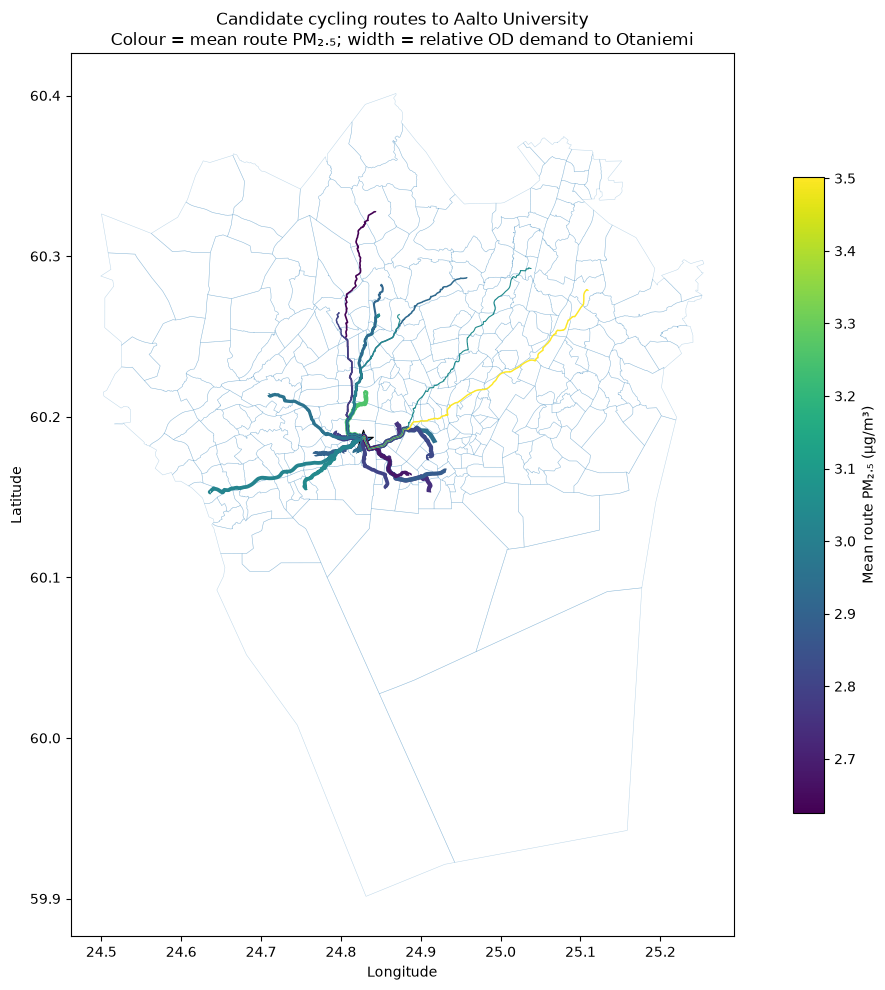

In [21]:
# MAP A — Mean route PM2.5
fig, ax = plt.subplots(figsize=(12, 10))

units_wgs84.boundary.plot(
    ax=ax,
    linewidth=0.35,
    alpha=0.30
)

routes_wgs84.plot(
    ax=ax,
    column="mean_route_pm25",
    cmap="viridis",
    linewidth=routes_wgs84["plot_linewidth"],
    legend=True,
    legend_kwds={
        "label": "Mean route PM₂.₅ (µg/m³)",
        "shrink": 0.72
    }
)

aalto_wgs84.plot(
    ax=ax,
    marker="*",
    markersize=220,
    edgecolor="black",
    linewidth=0.8
)

ax.set_title(
    "Candidate cycling routes to Aalto University\n"
    "Colour = mean route PM₂.₅; width = relative OD demand to Otaniemi"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()


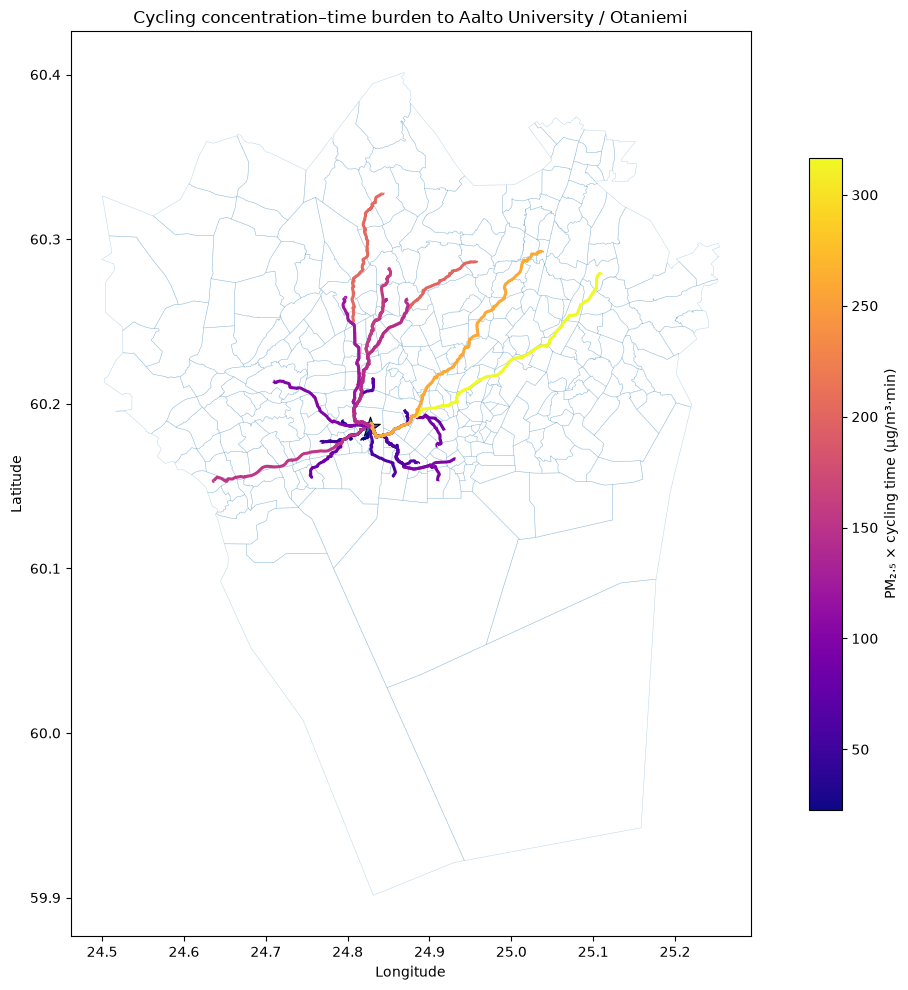

In [22]:
# MAP B — PM2.5 concentration-time burden
fig, ax = plt.subplots(figsize=(12, 10))

units_wgs84.boundary.plot(
    ax=ax,
    linewidth=0.35,
    alpha=0.30
)

routes_wgs84.plot(
    ax=ax,
    column="pm25_time_burden",
    cmap="plasma",
    linewidth=2.2,
    legend=True,
    legend_kwds={
        "label": "PM₂.₅ × cycling time (µg/m³·min)",
        "shrink": 0.72
    }
)

aalto_wgs84.plot(
    ax=ax,
    marker="*",
    markersize=220,
    edgecolor="black",
    linewidth=0.8
)

ax.set_title(
    "Cycling concentration–time burden to Aalto University / Otaniemi"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()


## 14. Compare distance, PM₂.₅, and burden


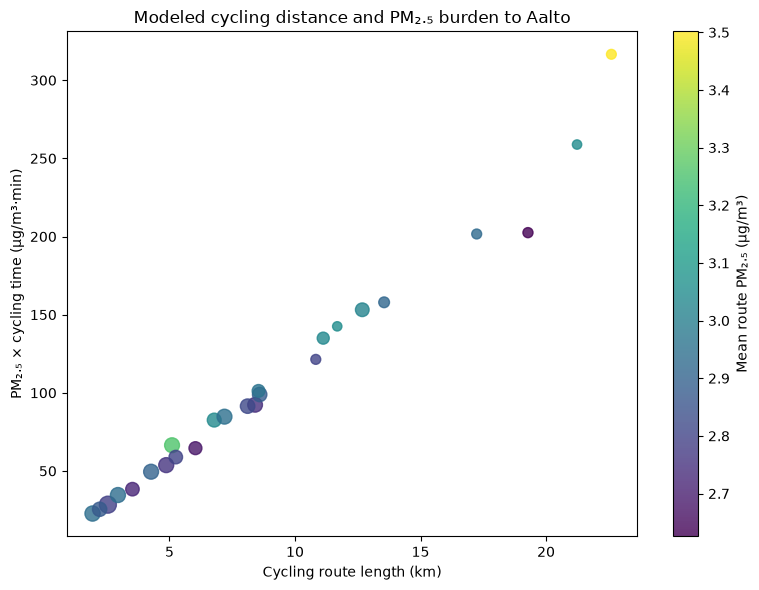

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    route_exposure["route_length_km"],
    route_exposure["pm25_time_burden"],
    s=30 + 120 * (
        route_exposure["trips_to_otaniemi"] /
        route_exposure["trips_to_otaniemi"].max()
    ),
    c=route_exposure["mean_route_pm25"],
    cmap="viridis",
    alpha=0.8
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Mean route PM₂.₅ (µg/m³)")

ax.set_xlabel("Cycling route length (km)")
ax.set_ylabel("PM₂.₅ × cycling time (µg/m³·min)")
ax.set_title("Modeled cycling distance and PM₂.₅ burden to Aalto")

plt.tight_layout()
plt.show()


## 15. Highest-burden modeled cycling approaches


In [24]:
ranking = (
    route_exposure[
        [
            "origin_name",
            "origin_municipality",
            "trips_to_otaniemi",
            "route_length_km",
            "cycle_time_min",
            "mean_route_pm25",
            "p95_route_pm25",
            "max_route_pm25",
            "pm25_time_burden",
            "flow_weighted_burden",
            "pm25_sample_coverage_pct"
        ]
    ]
    .sort_values("pm25_time_burden", ascending=False)
    .reset_index(drop=True)
)

display(ranking.head(20))


,origin_name,origin_municipality,trips_to_otaniemi,route_length_km,cycle_time_min,mean_route_pm25,p95_route_pm25,max_route_pm25,pm25_time_burden,flow_weighted_burden,pm25_sample_coverage_pct
0,Hakunila,Vantaa,479.364767,22.602295,90.409179,3.501762,5.000,5.3,316.591438,151762.780955,100.0
1,Tikkurila,Vantaa,371.969061,21.234510,84.938041,3.047561,3.900,5.3,258.853859,96285.626873,100.0
2,Kivistö,Vantaa,549.617976,19.279693,77.118770,2.625517,3.400,5.3,202.476606,111284.782332,100.0
3,Pakkala,Vantaa,505.347931,17.237236,68.948944,2.924134,4.200,5.3,201.615948,101886.201965,100.0
4,Martinlaakso,Vantaa,715.961282,13.549549,54.198197,2.913382,4.205,5.3,157.900069,113050.335798,100.0
5,Kivenlahti,Espoo,1599.848842,12.679608,50.718430,3.019309,3.700,5.3,153.134627,244992.255064,100.0
6,Kaivoksela,Vantaa,369.690909,11.682277,46.729109,3.050085,4.300,5.3,142.527761,52691.217378,100.0
7,Myyrmäki,Vantaa,1084.017502,11.123968,44.495874,3.033274,4.310,5.3,134.968163,146307.850664,100.0
8,Hämeenkylä,Vantaa,503.213811,10.827764,43.311057,2.802574,3.500,5.2,121.382420,61081.310270,100.0
9,Kauniainen,Kauniainen,1292.665175,8.546737,34.186948,2.960930,3.700,5.3,101.225167,130850.248660,100.0


## 16. Optional exports

These files make it easier to reproduce figures or build later analyses without rerouting every origin.


In [25]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

ranking.to_csv(
    os.path.join(OUTPUT_DIR, "cycling_to_otaniemi_exposure.csv"),
    index=False
)

routes_exposure.to_file(
    os.path.join(OUTPUT_DIR, "cycling_to_otaniemi_routes.gpkg"),
    layer="routes",
    driver="GPKG"
)

print("Saved outputs to:", OUTPUT_DIR)


Saved outputs to: ../outputs/04_otaniemi_cycling


# Interpretation guardrails

This Stage 04 analysis establishes **modeled cycling accessibility and potential route exposure to one important regional destination**.

The most defensible interpretations are:

1. how candidate bicycle-route distance/time to Aalto varies across selected neighbourhoods;
2. how the sampled FMI PM₂.₅ environment varies among those modeled routes;
3. how a concentration–time burden changes when both route concentration and cycling duration are considered;
4. how the modeled exposure geography overlaps with aggregate CAFEIN mobility demand to Otaniemi.

It does **not** show observed bicycle behaviour. The CAFEIN OD table provides aggregate mobility demand, not bicycle-mode trips. The OSM routes are shortest candidate cycling paths, and the FMI sample raster is a single model-hour surface.

A later extension could compare the shortest bicycle route with a **lower-exposure alternative route**, or replace the static raster with hourly PM₂.₅ / heat surfaces during actual high-exposure events.
